# Parameter Sensitivity Analysis

This notebook studies how the structural parameters of the generated book affect the estimated compiled page count, using a one-at-a-time (OAT) sweep, a finite-difference partial-derivative index, and a lean/baseline/rich configuration comparison (guideline 9). The deterministic analysis logic lives in `bookgen.research.sensitivity` and is unit-tested; this notebook is the presentation layer.

## Page-Count Model

We estimate the compiled page count as

$$\hat{P} = \left\lceil \frac{C \cdot S \cdot W}{450} \right\rceil + 3$$

where $C$ is the number of chapters, $S$ the sections per chapter, and $W$ the words per section. The constant $3$ accounts for front matter (cover, table of contents, figures, table, and formula).

In [1]:
from bookgen.research.sensitivity import oat_sensitivity

results = oat_sensitivity()
for parameter, series in results.items():
    print(parameter, series)

chapters [(3, 8), (4, 10), (5, 12), (6, 13), (7, 15), (8, 17), (9, 18), (10, 20)]
sections [(2, 10), (3, 13), (4, 17), (5, 20), (6, 23)]
words [(150, 9), (200, 11), (250, 13), (300, 15), (350, 17), (400, 19), (450, 21)]


## Partial-Derivative Sensitivity

Ignoring the ceiling, $\hat{P}$ is multilinear in the parameters, so the partial derivatives at the baseline $(C_0, S_0, W_0) = (6, 3, 250)$ are

$$\frac{\partial \hat{P}}{\partial C} = \frac{S_0 W_0}{450}, \quad \frac{\partial \hat{P}}{\partial S} = \frac{C_0 W_0}{450}, \quad \frac{\partial \hat{P}}{\partial W} = \frac{C_0 S_0}{450}.$$

We approximate these numerically with a symmetric finite difference, and also compare three end-to-end configurations.

In [2]:
from bookgen.research.sensitivity import compare_baselines, partial_sensitivity

print('partial sensitivities:', partial_sensitivity())
print('configuration comparison (pages):', compare_baselines())

partial sensitivities: {'chapters': 1.5, 'sections': 3.5, 'words': 0.5}
configuration comparison (pages): {'lean': 7, 'baseline': 13, 'rich': 28}


## Visualizations

The following call renders six figures concurrently under `generated/research/`: an OAT line chart, a sensitivity-magnitude bar chart, a scatter plot, a box plot, a heatmap of estimated pages over (chapters x words-per-section), and a waterfall of cumulative page contributions. Every figure uses a colorblind-safe palette and labeled axes/legend.

In [3]:
from bookgen.research.sensitivity_plots import generate_figures

figure_paths = generate_figures()
for path in figure_paths:
    print(path)

generated\research\oat_lines.png
generated\research\sensitivity_bars.png
generated\research\complexity_scatter.png
generated\research\pages_boxplot.png
generated\research\pages_heatmap.png
generated\research\waterfall.png


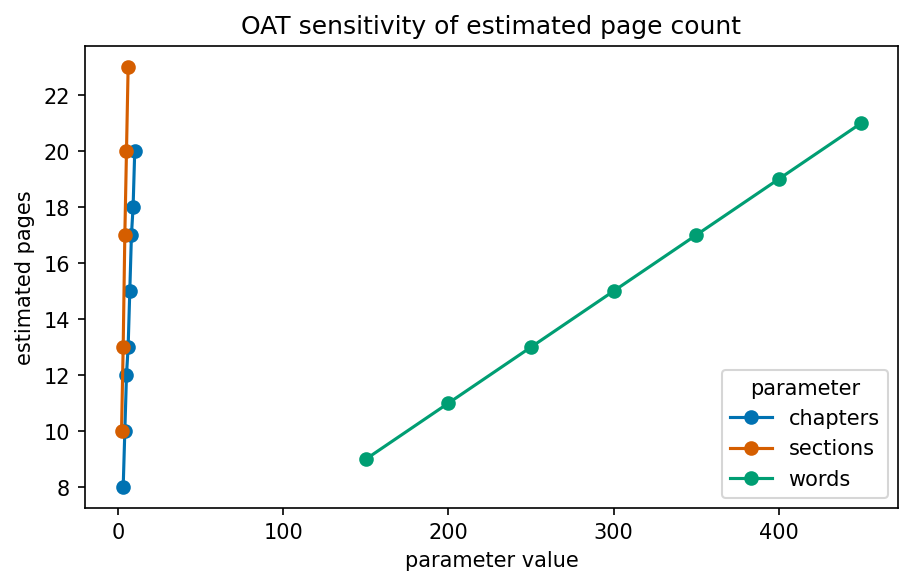

In [4]:
from IPython.display import Image

Image(filename=str(figure_paths[0]))

## Interpretation

The partial derivatives and the bar chart agree that **words per section** has the largest single-parameter effect on length over its sweep, followed by chapters, then sections. The heatmap shows the interaction between chapters and words per section: the target of roughly 15 pages is reached across a broad band, confirming the chosen baseline (6 chapters, 3 sections, ~250 words) is comfortably within range. The lean/baseline/rich comparison shows the design scales monotonically with content size.

## References

- Course materials, Lesson L06 (parameter research and sensitivity analysis).
- Submission guidelines, Section 9 (research and results analysis).